In [1]:
import pandas as pd
import sys
import os
import jax
from arviz.labels import MapLabeller
import arviz as az

sys.path.append(os.path.abspath(os.path.join('../..')))

from utils.modeling import (
    encode_categorical_covariates, 
    fit_model_and_extract_idata,
    )

from utils.plotting import (
    plot_predictive_distributions,
    plot_forest,
    plot_cutpoint_positions
)

/home/ubuntu/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Get data

In [2]:
df = pd.read_csv('data.csv')
# Check
print('Unique graders:', set(df['grader']))
print('Unique models:', set(df['LLM']))
df.head(5)

Unique graders: {'Human', 'Autograder'}
Unique models: {'LLM B', 'LLM A'}


,score,grader,LLM
0,7,Human,LLM A
1,6,Human,LLM A
2,5,Human,LLM A
3,6,Human,LLM A
4,7,Human,LLM A


# Fit model

In [3]:
# Define covariates and outcome
main_effects = ['grader', 'LLM']  # categorical variables
interactions = None
outcome = 'score'  # ordinal variable, 0–10

# Encode categorical covariates
covariates_dict, category_maps = encode_categorical_covariates(df, main_effects)

# Encode the outcome
allowed_scores = list(range(11))  # ordinal values: 0–10
score_map = {val: i for i, val in enumerate(allowed_scores)}
y = df[outcome].map(score_map).values

# Fit model and get idata
rng_key = jax.random.PRNGKey(0)
mcmc, idata = fit_model_and_extract_idata(
    rng_key, 
    covariates_dict, 
    y, 
    main_effects, 
    interactions, 
    category_maps
)

sample: 100%|██████████| 2000/2000 [00:04<00:00, 440.05it/s, 31 steps of size 1.95e-01. acc. prob=0.91]


## Fitted parameters

In [4]:
mcmc.print_summary()


                       mean       std    median      5.0%     95.0%     n_eff     r_hat
         b_LLM[0]      1.87      0.13      1.87      1.65      2.07    638.22      1.00
      b_grader[0]     -1.34      0.13     -1.34     -1.55     -1.14    580.56      1.00
cutpoint_diffs[0]      0.83      0.21      0.81      0.51      1.16    953.70      1.00
cutpoint_diffs[1]      0.85      0.18      0.85      0.56      1.12    889.78      1.00
cutpoint_diffs[2]      1.11      0.17      1.10      0.83      1.38    885.58      1.00
cutpoint_diffs[3]      1.08      0.17      1.08      0.82      1.37    874.84      1.00
cutpoint_diffs[4]      1.49      0.17      1.48      1.21      1.75    797.89      1.00
cutpoint_diffs[5]      1.83      0.21      1.82      1.49      2.17    864.91      1.00
cutpoint_diffs[6]      1.60      0.25      1.59      1.18      1.98    818.64      1.00
cutpoint_diffs[7]      0.89      0.26      0.85      0.46      1.28   1071.19      1.00
cutpoint_diffs[8]      0.62    

## Plot predictive distributions

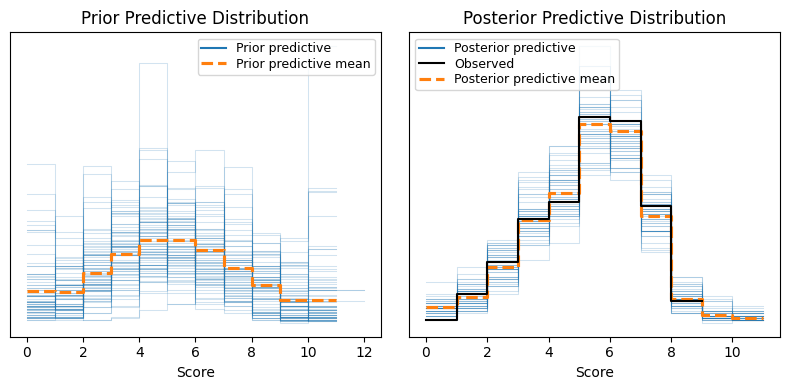

In [5]:
# Plot predictive distributions
plot_predictive_distributions(idata, fig_path="fig_predictive.png")

## Forest plot

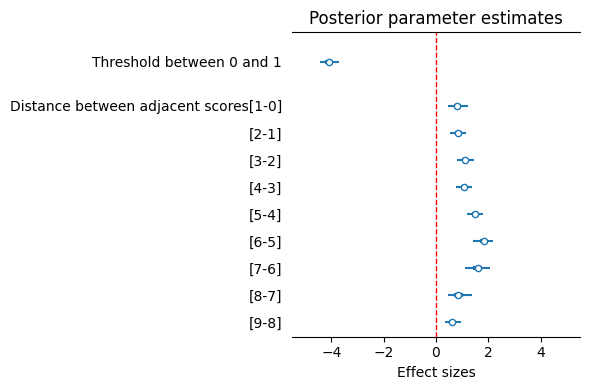

In [6]:
labeller = MapLabeller(
    var_name_map={
        "first_cutpoint": "Threshold between 0 and 1",
        "cutpoint_diffs": "Distance between adjacent scores"
    }
)

plot_forest(idata, var_names=["first_cutpoint", "cutpoint_diffs"], 
            labeller=labeller, fig_path=None, xlim=(-5.5, 5.5))

# Cutpoint positions

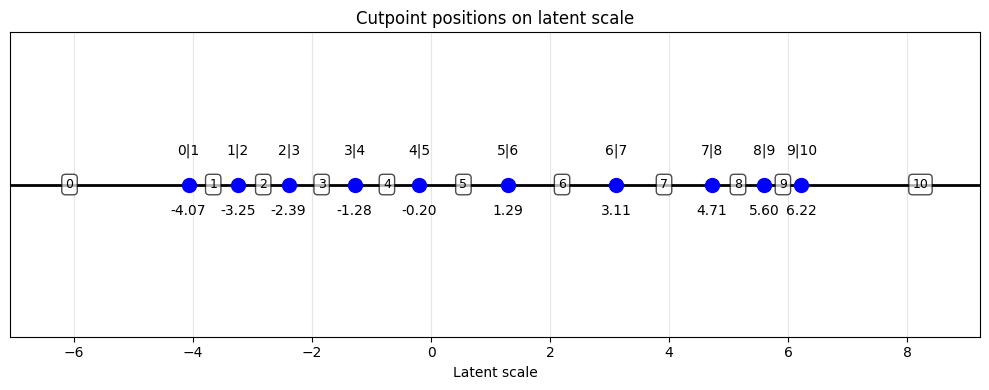

In [11]:
plot_cutpoint_positions(idata, fig_path="../../figures/figure6.png", fig_size=(10, 4))

| Cutpoint | Value | Interval Size | Score Range | Description | Interpretation |
|----------|-------|--------------|-------------|------------|----------------|
| c1 | -4.07 | - | 0-1 | Starting point | Minimum threshold to achieve score of 1 |
| c2 | -3.25 | 0.82 | 1-2 | Narrow | Small improvement needed to move from 1 to 2 |
| c3 | -2.39 | 0.86 | 2-3 | Narrow | Small improvement needed to move from 2 to 3 |
| c4 | -1.28 | 1.11 | 3-4 | Moderate | Moderate improvement needed to move from 3 to 4 |
| c5 | -0.20 | 1.08 | 4-5 | Moderate | Moderate improvement needed to move from 4 to 5 |
| c6 | 1.29 | 1.49 | 5-6 | Wide | Large improvement needed to move from 5 to 6 |
| c7 | 3.11 | 1.82 | 6-7 | Wide | Large improvement needed to move from 6 to 7 |
| c8 | 4.71 | 1.60 | 7-8 | Wide | Large improvement needed to move from 7 to 8 |
| c9 | 5.60 | 0.89 | 8-9 | Narrow | Small improvement needed to move from 8 to 9 |
| c10 | 6.22 | 0.62 | 9-10 | Narrow | Small improvement needed to move from 9 to 10 |

In [ ]:
# categories c5-c7 are not very discrimintory
# Example in the appendix? Or maybe not an example but a description of this model (in the appendix)